# 📊 Backtesting Demo: Профессиональное тестирование стратегий

## Требования

Перед запуском ноутбука убедитесь что:
1. ✅ Установлены все зависимости: `pip install -r requirements.txt`
2. ✅ Запущен ноутбук `02_feature_engineering.ipynb` для создания фичей
3. ✅ Файл `data/processed/aapl_with_features_5y.parquet` существует

## Содержание

Этот ноутбук демонстрирует:
- 📈 **Простые технические стратегии**: SMA Crossover, RSI Mean Reversion
- 🤖 **ML-стратегии**: Random Forest с предсказаниями
- 🔄 **Walk-Forward анализ**: Проверка устойчивости на разных окнах
- 📊 **Комплексные метрики**: Sharpe, Sortino, Calmar, MaxDD, Win Rate
- 📉 **Визуализация**: Equity curves, Drawdowns, сравнение стратегий

## Быстрый старт

1. Запустите все ячейки последовательно: `Cell → Run All`
2. Результаты будут сохранены автоматически
3. Визуализации появятся после каждого бэктеста

# Backtesting Demo: Профессиональное тестирование стратегий

Этот ноутбук демонстрирует:
- Простые технические стратегии (SMA Crossover, RSI)
- ML-стратегии с предсказаниями
- Walk-Forward анализ для проверки устойчивости
- Комплексные метрики эффективности

In [1]:
import sys
import os

# Добавляем корень проекта в sys.path
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Project root: {project_root}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Наши модули
from src.data.data_manager import DataManager
from src.features.feature_engine import FeatureEngine
from src.features.feature_registry import register_all_features

# Backtesting модули
from src.backtesting import (
    Portfolio, ExecutionEngine, PerformanceAnalyzer,
    Backtester, MLBacktester, WalkForwardAnalyzer
)

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Все модули загружены")

✓ Project root: /Users/semenzidkov/market-pricing-prj
✓ Все модули загружены
✓ Все модули загружены


## 1. Загрузка данных с фичами

In [2]:
# Загружаем готовый датасет с фичами (из Feature Engineering ноутбука)
data_path = os.path.join(project_root, 'data', 'processed', 'aapl_with_features_5y.parquet')

if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    print(f"✓ Загружено {len(df)} строк из кеша")
else:
    # Если нет готовых данных - создаем
    print("Кеш не найден, загружаем данные и считаем фичи...")
    
    config_path = os.path.join(project_root, 'config', 'config.yaml')
    dm = DataManager(config_path=config_path)
    df = dm.get_stock_data('AAPL', timeframe='1d', period='5y', use_cache=True)
    
    # Рассчитываем фичи
    cache_dir = os.path.join(project_root, 'data', 'processed', 'features')
    engine = FeatureEngine(cache_dir=cache_dir, version='1.0.0')
    register_all_features(engine)
    df = engine.compute_all(df, use_cache=True)
    
    # Сохраняем
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    df.to_parquet(data_path)
    print(f"✓ Данные сохранены в {data_path}")

# Убедимся что есть колонка symbol
if 'symbol' not in df.columns:
    df['symbol'] = 'AAPL'
    
print(f"\nПериод: {df.index.min().date()} - {df.index.max().date()}")
print(f"Колонок: {len(df.columns)}")
print(f"Строк: {len(df)}")

# Проверяем наличие необходимых фич для стратегий
required_features = ['sma_50', 'sma_200', 'rsi_14', 'close']
missing_features = [f for f in required_features if f not in df.columns]
if missing_features:
    print(f"\n⚠️  Отсутствуют фичи: {missing_features}")
    print("Требуется запустить Feature Engineering ноутбук")
else:
    print(f"\n✓ Все необходимые фичи присутствуют")

df.head()

✓ Загружено 250 строк из кеша

Период: 2024-11-05 - 2025-11-04
Колонок: 100
Строк: 250

✓ Все необходимые фичи присутствуют


,open,high,low,close,volume,dividend,symbol,asset_type,data_loaded_at,rsi_14,...,price_vs_sma_50,price_vs_sma_200,autocorr_lag_1,autocorr_lag_5,autocorr_lag_10,autocorr_lag_20,trend_strength,linear_regression_slope,volatility_ratio,hurst_exponent
date,,,,,,,,,,,,,,,,,,,,,
2024-11-05,221.800003,223.949997,221.139999,223.449997,28111300,0.00,AAPL,stocks,2025-11-05 11:22:44.362295,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-06,222.610001,226.070007,221.190002,222.720001,54561100,0.00,AAPL,stocks,2025-11-05 11:22:44.362295,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-07,224.630005,227.880005,224.570007,227.479996,42137700,0.00,AAPL,stocks,2025-11-05 11:22:44.362295,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-08,227.169998,228.660004,226.410004,226.960007,38328800,0.25,AAPL,stocks,2025-11-05 11:22:44.362295,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-11,225.000000,225.699997,221.500000,224.229996,42005600,0.00,AAPL,stocks,2025-11-05 11:22:44.362295,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Простая стратегия: SMA Crossover

In [3]:
from typing import TYPE_CHECKING
if TYPE_CHECKING:
    from src.backtesting import Portfolio

def sma_crossover_strategy(bar, portfolio, context):
    """
    Стратегия на пересечении SMA 50 и SMA 200
    - Golden Cross (SMA50 > SMA200): BUY
    - Death Cross (SMA50 < SMA200): SELL
    
    Args:
        bar: pd.Series - текущий бар с данными
        portfolio: Portfolio - портфель
        context: dict - контекст стратегии
    
    Returns:
        int: 1 = BUY, -1 = SELL, 0 = HOLD
    """
    symbol = bar.get('symbol', 'UNKNOWN')
    
    if 'sma_50' not in bar or 'sma_200' not in bar:
        return 0
    
    if pd.isna(bar['sma_50']) or pd.isna(bar['sma_200']):
        return 0
    
    # Проверяем пересечение через context
    prev_diff = context.get('prev_diff', 0)
    current_diff = bar['sma_50'] - bar['sma_200']
    context['prev_diff'] = current_diff
    
    # Golden Cross: SMA50 пересекает SMA200 снизу вверх
    if prev_diff <= 0 and current_diff > 0:
        if not portfolio.has_position(symbol):
            return 1  # BUY signal
    
    # Death Cross: SMA50 пересекает SMA200 сверху вниз
    if prev_diff >= 0 and current_diff < 0:
        if portfolio.has_position(symbol):
            return -1  # SELL signal
    
    return 0  # HOLD

# Запуск бэктеста
print("Запуск SMA Crossover стратегии...\n")

bt_sma = Backtester(
    data=df,
    strategy=sma_crossover_strategy,
    initial_capital=100000,
    commission_rate=0.001,  # 0.1%
    slippage_rate=0.0005,   # 0.05%
    position_size=0.95,     # 95% капитала
    name="SMA_Crossover"
)

results_sma = bt_sma.run(verbose=True)

# Вывод результатов
bt_sma.print_summary()

INFO:src.backtesting.portfolio:Portfolio 'SMA_Crossover_Portfolio' создан: начальный капитал $100,000.00
INFO:src.backtesting.execution:ExecutionEngine инициализирован (fill_at=close)
INFO:src.backtesting.performance:PerformanceAnalyzer инициализирован
INFO:src.backtesting.backtester:Backtester 'SMA_Crossover' инициализирован
INFO:src.backtesting.backtester:Запуск бэктеста 'SMA_Crossover'...
INFO:src.backtesting.portfolio:Portfolio 'SMA_Crossover_Portfolio' сброшен
INFO:src.backtesting.execution:ExecutionEngine сброшен
INFO:src.backtesting.execution:ExecutionEngine инициализирован (fill_at=close)
INFO:src.backtesting.performance:PerformanceAnalyzer инициализирован
INFO:src.backtesting.backtester:Backtester 'SMA_Crossover' инициализирован
INFO:src.backtesting.backtester:Запуск бэктеста 'SMA_Crossover'...
INFO:src.backtesting.portfolio:Portfolio 'SMA_Crossover_Portfolio' сброшен
INFO:src.backtesting.execution:ExecutionEngine сброшен


Запуск SMA Crossover стратегии...



Backtesting:   0%|          | 0/250 [00:00<?, ?it/s]INFO:src.backtesting.portfolio:Открыта long позиция AAPL: 401.35192743907425 @ $238.27
INFO:src.backtesting.execution:Ордер исполнен: long 401.35192743907425 AAPL @ $238.27 (slippage: $47.79)
Backtesting: 100%|██████████| 250/250 [00:00<00:00, 13586.29it/s]INFO:src.backtesting.portfolio:Открыта long позиция AAPL: 401.35192743907425 @ $238.27
INFO:src.backtesting.execution:Ордер исполнен: long 401.35192743907425 AAPL @ $238.27 (slippage: $47.79)
Backtesting: 100%|██████████| 250/250 [00:00<00:00, 13586.29it/s]
INFO:src.backtesting.backtester:Бэктест 'SMA_Crossover' завершен

INFO:src.backtesting.backtester:Бэктест 'SMA_Crossover' завершен



  BACKTEST PERFORMANCE REPORT: SMA_Crossover_Portfolio

📊 PORTFOLIO METRICS:
  Initial Capital:       $     100,000.00
  Final Equity:          $     112,607.88
  Net Profit:            $           0.00
  Total Return:                    12.61%
  Annual Return:                   12.65%

📈 RISK-ADJUSTED RETURNS:
  Sharpe Ratio:                    1.194
  Sortino Ratio:                   2.322
  Calmar Ratio:                  265.732

📉 DRAWDOWN METRICS:
  Max Drawdown:                     4.76%
  Max DD Duration:                     7 periods
  Current Drawdown:                 0.48%
  Ulcer Index:                      0.62
  Recovery Factor:                  2.34

💰 TRADE STATISTICS:
  Total Trades:                        0
  Winning Trades:                      0
  Losing Trades:                       0
  Win Rate:                         0.00%
  Profit Factor:                    0.00

💵 AVERAGE TRADE:
  Average Trade:         $           0.00
  Average Win:           $           0.0

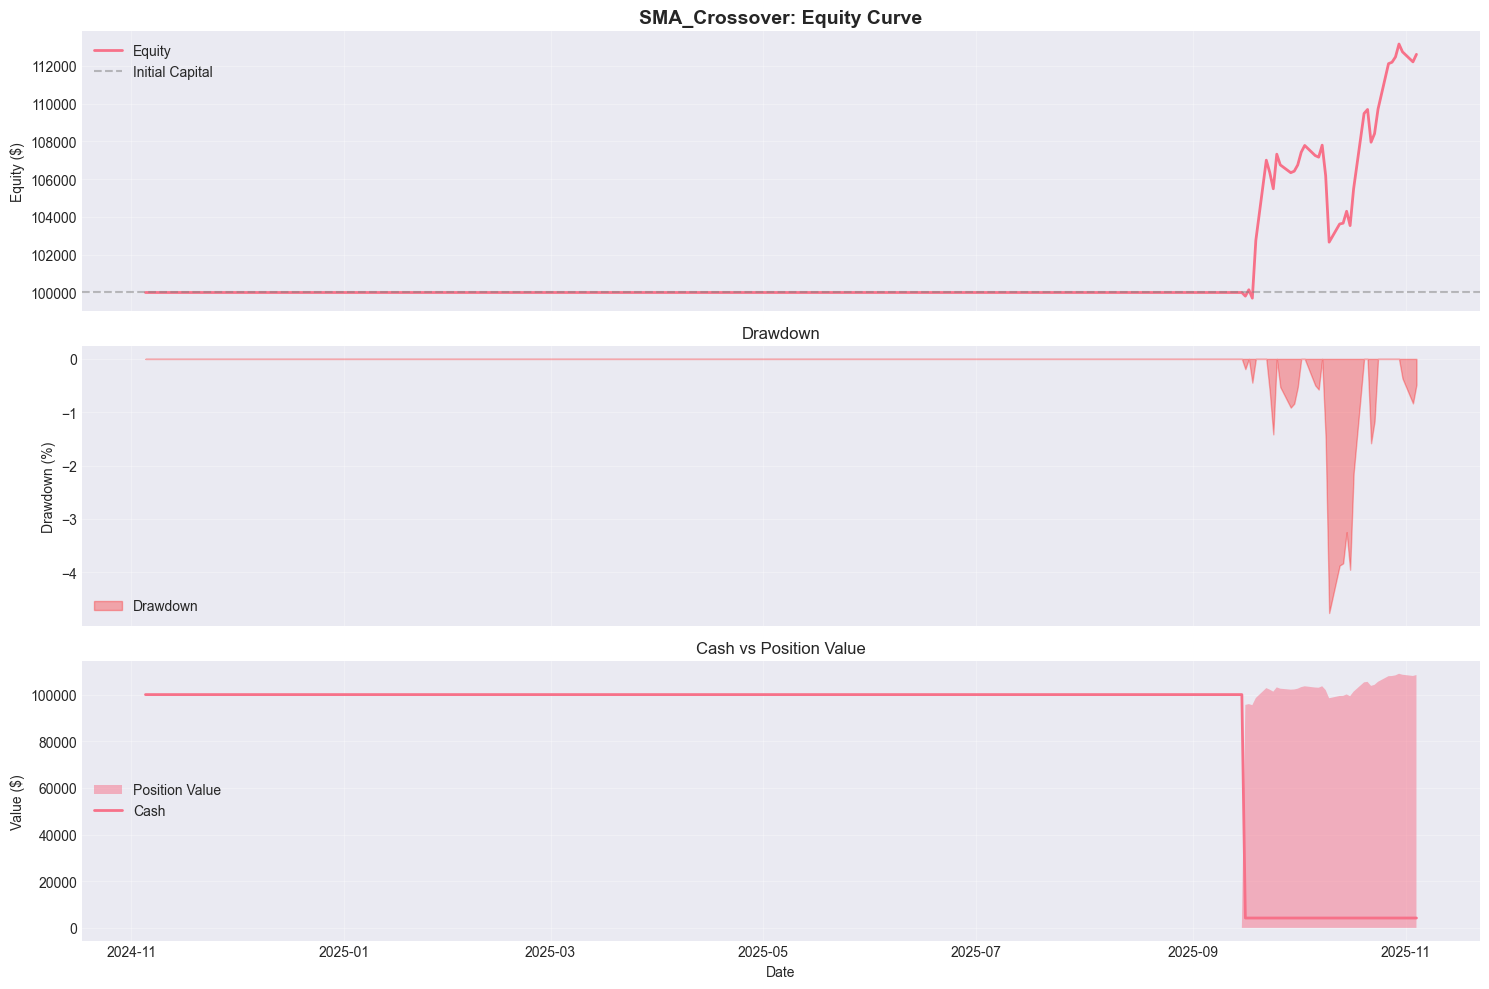

In [4]:
# Визуализация результатов SMA стратегии
bt_sma.plot_results(figsize=(15, 10))

## 3. Стратегия на основе RSI

In [5]:
def rsi_mean_reversion_strategy(bar, portfolio, context):
    """
    Mean reversion стратегия на RSI
    - RSI < 30: Oversold, BUY
    - RSI > 70: Overbought, SELL
    
    Args:
        bar: pd.Series - текущий бар
        portfolio: Portfolio - портфель
        context: dict - контекст
    
    Returns:
        int: 1 = BUY, -1 = SELL, 0 = HOLD
    """
    symbol = bar.get('symbol', 'UNKNOWN')
    
    if 'rsi_14' not in bar or pd.isna(bar['rsi_14']):
        return 0
    
    rsi = bar['rsi_14']
    
    # Oversold - покупаем
    if rsi < 30 and not portfolio.has_position(symbol):
        return 1
    
    # Overbought - продаем
    if rsi > 70 and portfolio.has_position(symbol):
        return -1
    
    return 0

# Запуск RSI бэктеста
print("Запуск RSI Mean Reversion стратегии...\n")

bt_rsi = Backtester(
    data=df,
    strategy=rsi_mean_reversion_strategy,
    initial_capital=100000,
    commission_rate=0.001,
    slippage_rate=0.0005,
    position_size=0.95,
    name="RSI_MeanReversion"
)

results_rsi = bt_rsi.run(verbose=True)
bt_rsi.print_summary()

INFO:src.backtesting.portfolio:Portfolio 'RSI_MeanReversion_Portfolio' создан: начальный капитал $100,000.00
INFO:src.backtesting.execution:ExecutionEngine инициализирован (fill_at=close)
INFO:src.backtesting.performance:PerformanceAnalyzer инициализирован
INFO:src.backtesting.backtester:Backtester 'RSI_MeanReversion' инициализирован
INFO:src.backtesting.backtester:Запуск бэктеста 'RSI_MeanReversion'...
INFO:src.backtesting.portfolio:Portfolio 'RSI_MeanReversion_Portfolio' сброшен
INFO:src.backtesting.execution:ExecutionEngine сброшен
INFO:src.backtesting.execution:ExecutionEngine инициализирован (fill_at=close)
INFO:src.backtesting.performance:PerformanceAnalyzer инициализирован
INFO:src.backtesting.backtester:Backtester 'RSI_MeanReversion' инициализирован
INFO:src.backtesting.backtester:Запуск бэктеста 'RSI_MeanReversion'...
INFO:src.backtesting.portfolio:Portfolio 'RSI_MeanReversion_Portfolio' сброшен
INFO:src.backtesting.execution:ExecutionEngine сброшен


Запуск RSI Mean Reversion стратегии...



Backtesting:   0%|          | 0/250 [00:00<?, ?it/s]INFO:src.backtesting.portfolio:Открыта long позиция AAPL: 405.29011294238285 @ $233.40
INFO:src.backtesting.execution:Ордер исполнен: long 405.29011294238285 AAPL @ $233.40 (slippage: $47.27)
INFO:src.backtesting.portfolio:Открыта long позиция AAPL: 405.29011294238285 @ $233.40
INFO:src.backtesting.execution:Ордер исполнен: long 405.29011294238285 AAPL @ $233.40 (slippage: $47.27)
Backtesting: 100%|██████████| 250/250 [00:02<00:00, 100.38it/s]
INFO:src.backtesting.backtester:Бэктест 'RSI_MeanReversion' завершен

INFO:src.backtesting.backtester:Бэктест 'RSI_MeanReversion' завершен



  BACKTEST PERFORMANCE REPORT: RSI_MeanReversion_Portfolio

📊 PORTFOLIO METRICS:
  Initial Capital:       $     100,000.00
  Final Equity:          $     114,709.31
  Net Profit:            $           0.00
  Total Return:                    14.71%
  Annual Return:                   14.76%

📈 RISK-ADJUSTED RETURNS:
  Sharpe Ratio:                    0.545
  Sortino Ratio:                   0.732
  Calmar Ratio:                   51.417

📉 DRAWDOWN METRICS:
  Max Drawdown:                    28.71%
  Max DD Duration:                   144 periods
  Current Drawdown:                 0.48%
  Ulcer Index:                     10.60
  Recovery Factor:                  0.44

💰 TRADE STATISTICS:
  Total Trades:                        0
  Winning Trades:                      0
  Losing Trades:                       0
  Win Rate:                         0.00%
  Profit Factor:                    0.00

💵 AVERAGE TRADE:
  Average Trade:         $           0.00
  Average Win:           $          

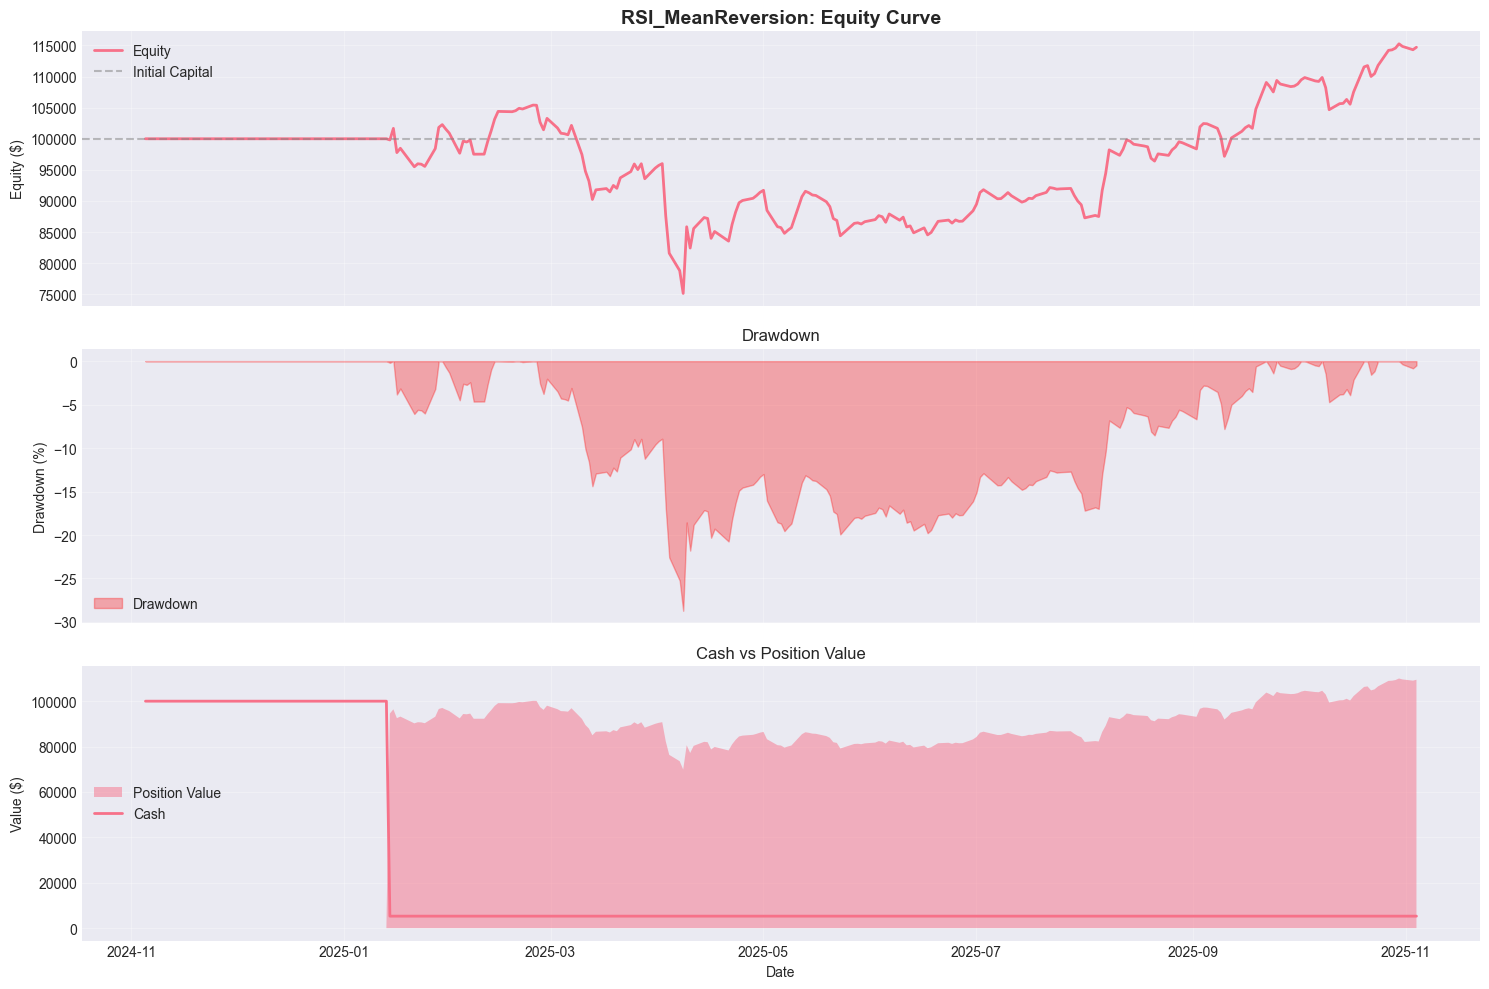

In [6]:
# Визуализация RSI стратегии
bt_rsi.plot_results(figsize=(15, 10))

## 4. ML Стратегия с Random Forest

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Подготовка данных для ML
print("Подготовка данных для ML модели...")

# Выбираем фичи
feature_cols = [
    'rsi_14', 'macd', 'macd_signal', 'atr_14', 'adx',
    'returns_1d', 'realized_vol_20', 'rolling_zscore_20',
    'trend_strength', 'volatility_ratio'
]

# Создаем таргет: будущая доходность > 0
df_ml = df.copy()
df_ml['target'] = (df_ml['forward_returns_1d'] > 0).astype(int)

# Удаляем NaN
df_ml_clean = df_ml[feature_cols + ['target', 'close', 'symbol']].dropna()

print(f"Датасет для ML: {len(df_ml_clean)} строк, {len(feature_cols)} фич")

# Train/Test split (70/30)
split_idx = int(len(df_ml_clean) * 0.7)
train_df = df_ml_clean.iloc[:split_idx]
test_df = df_ml_clean.iloc[split_idx:]

print(f"Train: {len(train_df)} samples")
print(f"Test: {len(test_df)} samples")

# Обучение модели
X_train = train_df[feature_cols]
y_train = train_df['target']

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=50,
    random_state=42,
    n_jobs=-1
)

print("\nОбучение Random Forest...")
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
print(f"✓ Train accuracy: {train_score:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 важных фич:")
print(feature_importance.head())

Подготовка данных для ML модели...
Датасет для ML: 190 строк, 10 фич
Train: 133 samples
Test: 57 samples

Обучение Random Forest...
✓ Train accuracy: 0.714

Top 5 важных фич:
           feature  importance
1             macd    0.175838
2      macd_signal    0.168371
0           rsi_14    0.116949
4              adx    0.115983
6  realized_vol_20    0.095629


In [8]:
# ML Backtest
print("Запуск ML бэктеста...\n")

ml_bt = MLBacktester(
    data=test_df,
    model=model,
    feature_columns=feature_cols,
    initial_capital=100000,
    commission_rate=0.001,
    slippage_rate=0.0005,
    position_size=0.95,
    prediction_threshold=0.55,  # Требуем 55% уверенности
    name="ML_RandomForest"
)

results_ml = ml_bt.run(verbose=True)

# Выводим результаты
ml_bt.print_summary()
ml_bt.print_ml_summary()

INFO:src.backtesting.portfolio:Portfolio 'ML_RandomForest_Portfolio' создан: начальный капитал $100,000.00
INFO:src.backtesting.execution:ExecutionEngine инициализирован (fill_at=close)
INFO:src.backtesting.performance:PerformanceAnalyzer инициализирован
INFO:src.backtesting.backtester:Backtester 'ML_RandomForest' инициализирован
INFO:src.backtesting.ml_backtester:ML Backtester 'ML_RandomForest' инициализирован с 10 фичами
INFO:src.backtesting.backtester:Запуск бэктеста 'ML_RandomForest'...
INFO:src.backtesting.portfolio:Portfolio 'ML_RandomForest_Portfolio' сброшен
INFO:src.backtesting.execution:ExecutionEngine сброшен
INFO:src.backtesting.execution:ExecutionEngine инициализирован (fill_at=close)
INFO:src.backtesting.performance:PerformanceAnalyzer инициализирован
INFO:src.backtesting.backtester:Backtester 'ML_RandomForest' инициализирован
INFO:src.backtesting.ml_backtester:ML Backtester 'ML_RandomForest' инициализирован с 10 фичами
INFO:src.backtesting.backtester:Запуск бэктеста 'ML_

Запуск ML бэктеста...



Backtesting: 100%|██████████| 57/57 [00:00<00:00, 66.26it/s]
INFO:src.backtesting.backtester:Бэктест 'ML_RandomForest' завершен

INFO:src.backtesting.backtester:Бэктест 'ML_RandomForest' завершен



  BACKTEST PERFORMANCE REPORT: ML_RandomForest_Portfolio

📊 PORTFOLIO METRICS:
  Initial Capital:       $     100,000.00
  Final Equity:          $     100,000.00
  Net Profit:            $           0.00
  Total Return:                     0.00%
  Annual Return:                    0.00%

📈 RISK-ADJUSTED RETURNS:
  Sharpe Ratio:                    0.000
  Sortino Ratio:                   0.000
  Calmar Ratio:                    0.000

📉 DRAWDOWN METRICS:
  Max Drawdown:                     0.00%
  Max DD Duration:                     0 periods
  Current Drawdown:                 0.00%
  Ulcer Index:                      0.00
  Recovery Factor:                  0.00

💰 TRADE STATISTICS:
  Total Trades:                        0
  Winning Trades:                      0
  Losing Trades:                       0
  Win Rate:                         0.00%
  Profit Factor:                    0.00

💵 AVERAGE TRADE:
  Average Trade:         $           0.00
  Average Win:           $           0

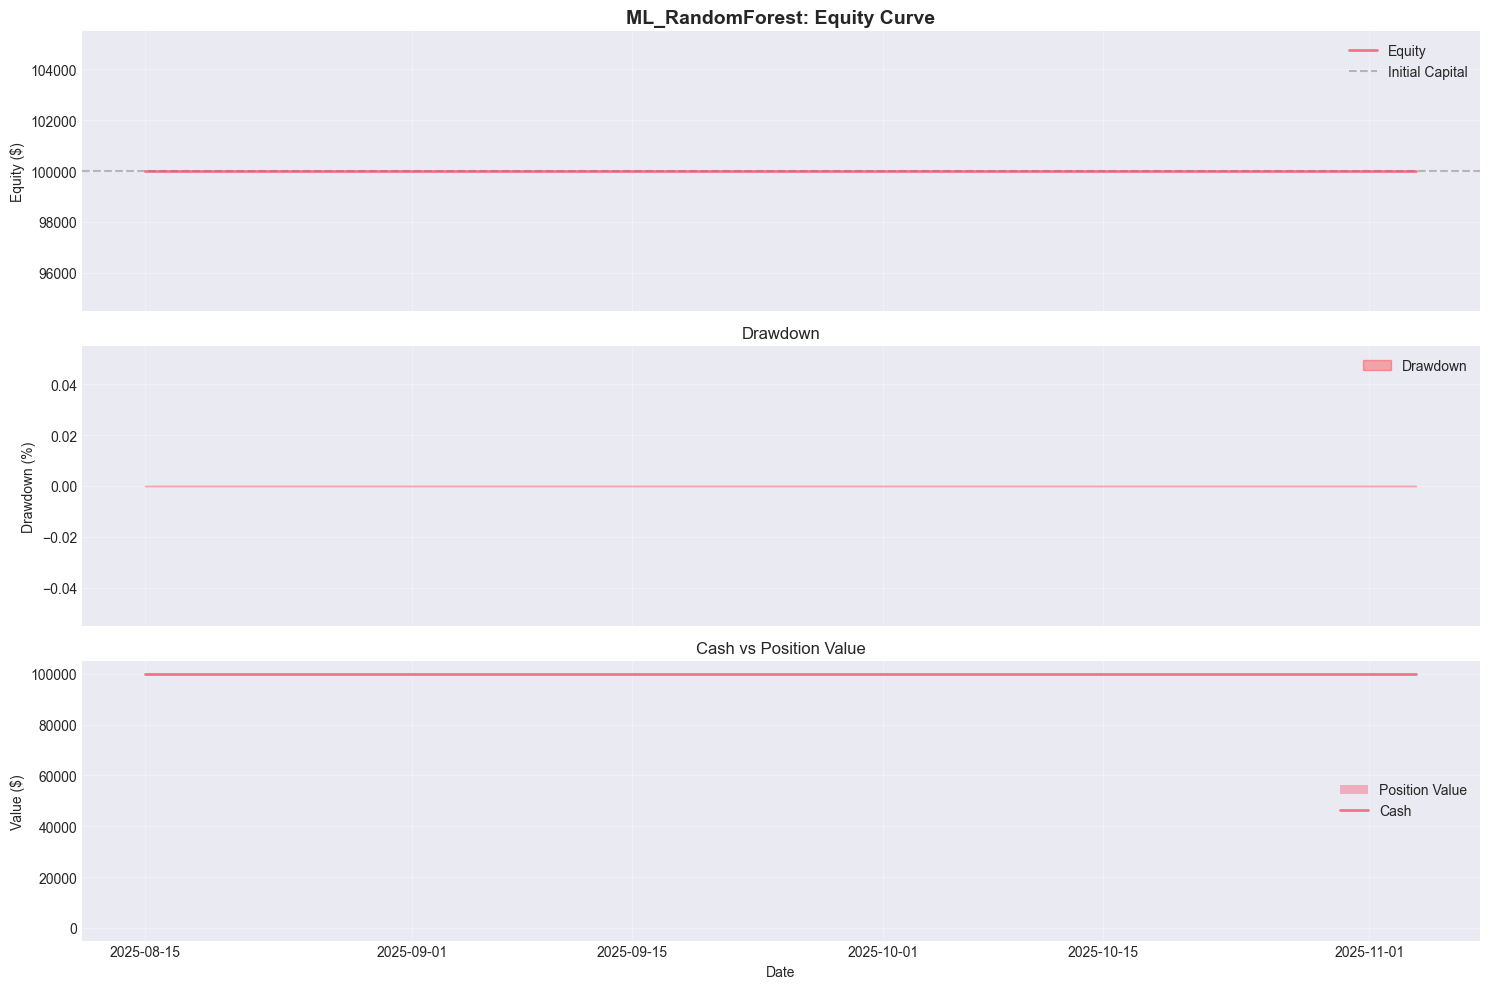

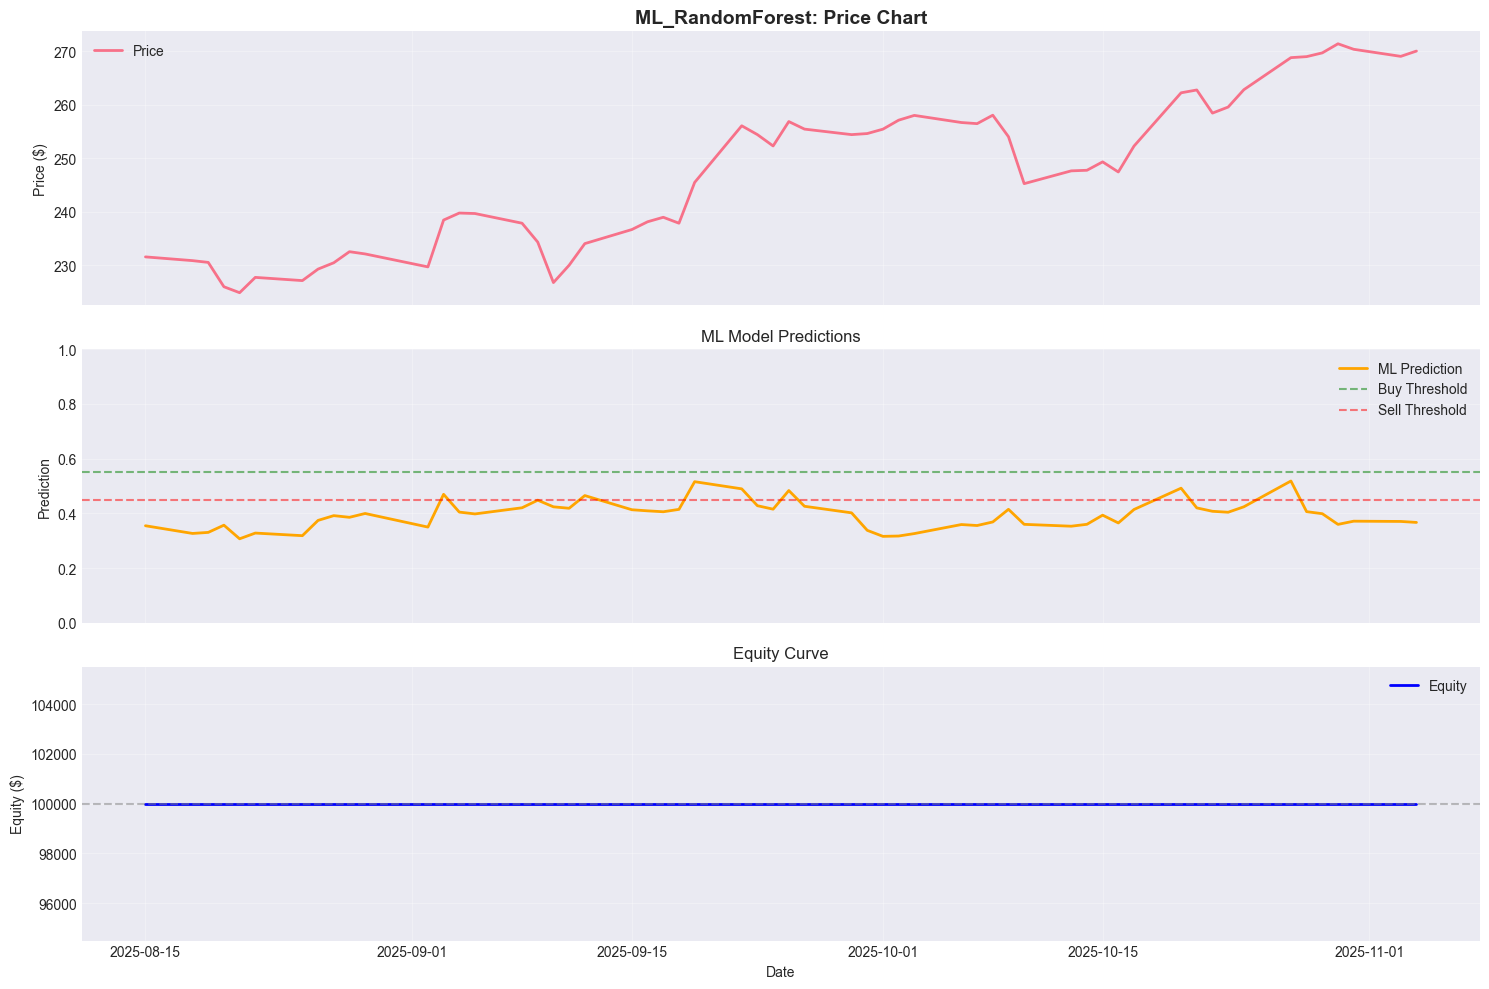

In [9]:
# Визуализация ML стратегии
ml_bt.plot_results(figsize=(15, 10))
ml_bt.plot_predictions(figsize=(15, 10))

## 5. Walk-Forward Analysis

Проверка устойчивости стратегии на разных временных окнах

In [10]:
# Walk-Forward анализ для SMA стратегии
print("Запуск Walk-Forward анализа для SMA Crossover...\n")

wf_analyzer = WalkForwardAnalyzer(
    data=df,
    train_period=252,  # 1 год для обучения
    test_period=63,    # 3 месяца для теста
    step_size=63,      # Шаг 3 месяца
    anchored=False,    # Rolling windows
    name="WF_SMA_Crossover"
)

wf_results = wf_analyzer.run(
    strategy_func=sma_crossover_strategy,
    initial_capital=100000,
    commission_rate=0.001,
    slippage_rate=0.0005,
    position_size=0.95,
    verbose=True
)

# Результаты
wf_analyzer.print_summary()

INFO:src.backtesting.walk_forward:WalkForwardAnalyzer инициализирован: train=252d, test=63d, step=63d, anchored=False
INFO:src.backtesting.walk_forward:Запуск walk-forward анализа 'WF_SMA_Crossover'...
INFO:src.backtesting.walk_forward:Создано 0 walk-forward windows
INFO:src.backtesting.walk_forward:Запуск walk-forward анализа 'WF_SMA_Crossover'...
INFO:src.backtesting.walk_forward:Создано 0 walk-forward windows


Запуск Walk-Forward анализа для SMA Crossover...



Walk-Forward Windows: 0it [00:00, ?it/s]
INFO:src.backtesting.walk_forward:Walk-forward анализ 'WF_SMA_Crossover' завершен
Walk-Forward Windows: 0it [00:00, ?it/s]
INFO:src.backtesting.walk_forward:Walk-forward анализ 'WF_SMA_Crossover' завершен


In [11]:
# Визуализация Walk-Forward результатов
wf_analyzer.plot_results(figsize=(15, 12))

## 6. Walk-Forward для ML модели

In [12]:
# ML Walk-Forward Analysis
print("Запуск ML Walk-Forward анализа...\n")

wf_ml_analyzer = WalkForwardAnalyzer(
    data=df_ml_clean,
    train_period=504,  # 2 года
    test_period=126,   # 6 месяцев
    step_size=126,
    anchored=False,
    name="WF_ML_RandomForest"
)

wf_ml_results = wf_ml_analyzer.run_ml(
    model_class=RandomForestClassifier,
    feature_columns=feature_cols,
    target_column='target',
    model_params={
        'n_estimators': 100,
        'max_depth': 10,
        'min_samples_split': 50,
        'random_state': 42,
        'n_jobs': -1
    },
    initial_capital=100000,
    commission_rate=0.001,
    slippage_rate=0.0005,
    position_size=0.95,
    prediction_threshold=0.55,
    verbose=True
)

wf_ml_analyzer.print_summary()

INFO:src.backtesting.walk_forward:WalkForwardAnalyzer инициализирован: train=504d, test=126d, step=126d, anchored=False
INFO:src.backtesting.walk_forward:Запуск ML walk-forward анализа 'WF_ML_RandomForest'...
INFO:src.backtesting.walk_forward:Создано 0 walk-forward windows
INFO:src.backtesting.walk_forward:Запуск ML walk-forward анализа 'WF_ML_RandomForest'...
INFO:src.backtesting.walk_forward:Создано 0 walk-forward windows


Запуск ML Walk-Forward анализа...



ML Walk-Forward Windows: 0it [00:00, ?it/s]
INFO:src.backtesting.walk_forward:ML walk-forward анализ 'WF_ML_RandomForest' завершен

INFO:src.backtesting.walk_forward:ML walk-forward анализ 'WF_ML_RandomForest' завершен


In [13]:
# Визуализация ML Walk-Forward
wf_ml_analyzer.plot_results(figsize=(15, 12))

## 7. Сравнение стратегий

In [14]:
# Сравнительная таблица
comparison = pd.DataFrame({
    'Strategy': ['SMA Crossover', 'RSI Mean Reversion', 'ML Random Forest'],
    'Total Return (%)': [
        results_sma.get('total_return_pct', 0),
        results_rsi.get('total_return_pct', 0),
        results_ml.get('total_return_pct', 0)
    ],
    'Sharpe Ratio': [
        results_sma.get('sharpe_ratio', 0),
        results_rsi.get('sharpe_ratio', 0),
        results_ml.get('sharpe_ratio', 0)
    ],
    'Max Drawdown (%)': [
        results_sma.get('max_drawdown', 0) * 100,
        results_rsi.get('max_drawdown', 0) * 100,
        results_ml.get('max_drawdown', 0) * 100
    ],
    'Win Rate (%)': [
        results_sma.get('win_rate', 0) * 100,
        results_rsi.get('win_rate', 0) * 100,
        results_ml.get('win_rate', 0) * 100
    ],
    'Total Trades': [
        results_sma.get('total_trades', 0),
        results_rsi.get('total_trades', 0),
        results_ml.get('total_trades', 0)
    ]
})

print("\n" + "=" * 80)
print("  STRATEGY COMPARISON")
print("=" * 80 + "\n")
print(comparison.to_string(index=False))
print("\n" + "=" * 80 + "\n")


  STRATEGY COMPARISON

          Strategy  Total Return (%)  Sharpe Ratio  Max Drawdown (%)  Win Rate (%)  Total Trades
     SMA Crossover         12.607883      1.193553          4.761877           0.0             0
RSI Mean Reversion         14.709305      0.544584         28.713129           0.0             0
  ML Random Forest          0.000000      0.000000          0.000000           0.0             0




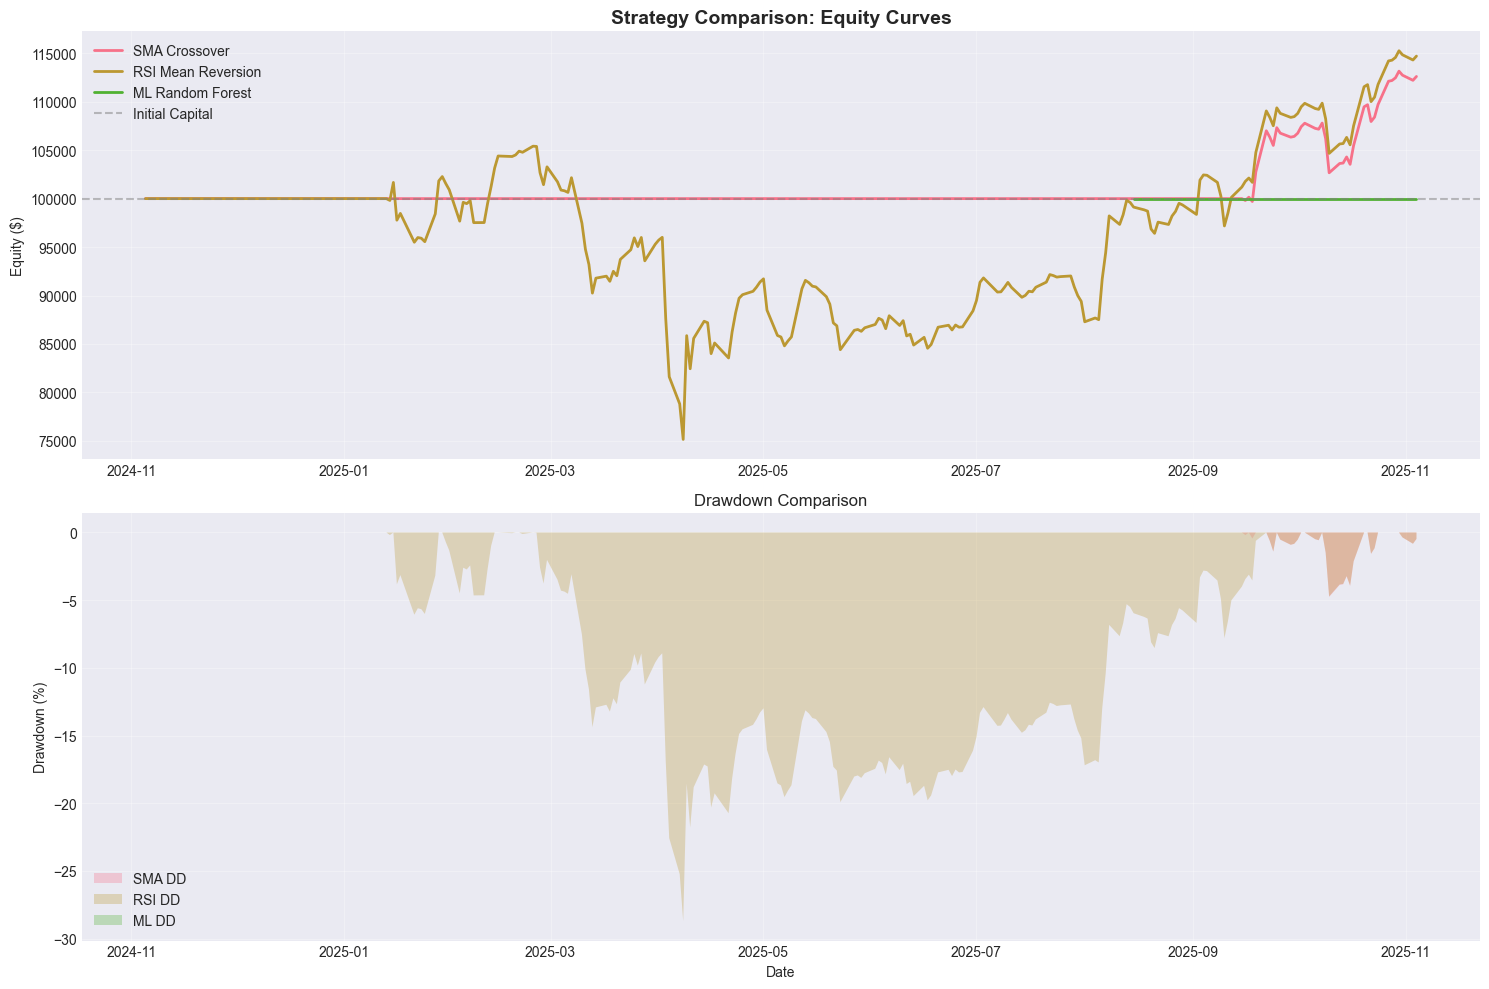

In [15]:
# Визуальное сравнение equity curves
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Equity curves
ax1 = axes[0]
equity_sma = results_sma['equity_curve']
equity_rsi = results_rsi['equity_curve']
equity_ml = results_ml['equity_curve']

ax1.plot(equity_sma.index, equity_sma['equity'], label='SMA Crossover', linewidth=2)
ax1.plot(equity_rsi.index, equity_rsi['equity'], label='RSI Mean Reversion', linewidth=2)
ax1.plot(equity_ml.index, equity_ml['equity'], label='ML Random Forest', linewidth=2)
ax1.axhline(100000, color='gray', linestyle='--', alpha=0.5, label='Initial Capital')
ax1.set_ylabel('Equity ($)')
ax1.set_title('Strategy Comparison: Equity Curves', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Drawdowns
ax2 = axes[1]
ax2.fill_between(equity_sma.index, 0, -equity_sma['drawdown'] * 100, 
                alpha=0.3, label='SMA DD')
ax2.fill_between(equity_rsi.index, 0, -equity_rsi['drawdown'] * 100, 
                alpha=0.3, label='RSI DD')
ax2.fill_between(equity_ml.index, 0, -equity_ml['drawdown'] * 100, 
                alpha=0.3, label='ML DD')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.set_title('Drawdown Comparison', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ✅ Итоги

**Реализованные возможности:**
- ✅ Профессиональный Portfolio management с учетом комиссий и slippage
- ✅ Execution Engine для market, limit, stop orders
- ✅ Comprehensive metrics: Sharpe, Sortino, Calmar, MaxDD, Win Rate, Profit Factor
- ✅ ML Backtesting с автоматическими предсказаниями
- ✅ Walk-Forward Analysis для проверки устойчивости
- ✅ Подробная визуализация результатов

**Следующие шаги:**
1. Оптимизация параметров стратегий
2. Multi-asset портфели
3. Position sizing methods (Kelly, Fixed Fractional)
4. Risk management rules (stop-loss, take-profit)
5. Live trading integration